In [44]:

#STAGE 1 : Loading Data as Desired
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import datetime 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on {device}")

#Data as Tensor
labels = torch.load("tensors/labels_training.pt",weights_only=True)
images = torch.cat((torch.load("tensors/training_decoys.pt",weights_only=True),torch.load("tensors/training_ligands.pt",weights_only=True)),dim=0)



Running on cpu


In [45]:
mean = images.mean(dim=(0,1,3,4))
std = images.std(dim=(0,1,3,4))
images = (images - mean[None,None,:,None,None]) / std[None,None,:,None,None] 


labels = labels[:,0]  #one label per molecule
labels = labels.long()

Ligand_train = torch.utils.data.TensorDataset(images, labels)
train_loader_Ligand = torch.utils.data.DataLoader(Ligand_train, batch_size = 64, shuffle = True)

In [46]:
class Net(nn.Module):     
    def __init__(self):   
        super().__init__() 
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)       
        self.act1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)                               
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)    
        self.act2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)     
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)    
        self.act3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(p=0.6)
        self.fc1 = nn.Linear(64 * 12 * 12, 128)                         
        self.act4 = nn.ReLU()
        self.fc2 = nn.Linear(128, 2)   
    

    def forward(self, x):  
        if x.dim() == 4:
            x = x.unsqueeze(1)
                
        batch_size, rotations, C, H, W = x.shape
        x = x.view(batch_size * rotations, C, H, W)
        x = self.pool1(self.act1(self.conv1(x)))
        x = self.pool2(self.act2(self.conv2(x)))
        x = self.pool3(self.act3(self.conv3(x)))
        x = x.view(-1, 64 * 12 * 12)
        x = self.act4(self.fc1(x))
        x = x.view(batch_size, rotations, -1)

        x = x.max(dim=1)[0]

        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [48]:
labels_val = torch.load("tensors/labels_validation.pt",weights_only=True)
images_val = torch.cat((torch.load("tensors/validation_decoys.pt",weights_only=True),torch.load("tensors/validation_ligands.pt",weights_only=True)),dim=0)


images_val = (images_val - mean[None,:,None,None]) / std[None,:,None,None] 

labels_val = labels_val[:,0]  #one label per molecule
labels_val = labels_val.long()


Ligand_val = torch.utils.data.TensorDataset(images_val, labels_val)
val_loader_Ligand = torch.utils.data.DataLoader(Ligand_val, batch_size = 64, shuffle = False)

In [ ]:

from sklearn.metrics import roc_auc_score

def validate2(model,train_loader, val_loader):

    model.eval()

    true_labels = []
    pred_probs = []

    with torch.no_grad():

        for imgs, labels in val_loader:
            
            imgs = imgs.to(device)
            labels = labels.to(device)
            outputs = model(imgs)

            probs = torch.softmax(outputs, dim=1)[:,1]

            pred_probs.extend(probs.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    auc = roc_auc_score(true_labels, pred_probs)

    print(f"Validation AUROC = {auc:.4f}")

    model.train()



In [51]:
#Defining Training Loop
def training_loop(n_epochs, optimizer, model, loss_fn, train_loader):
    
    for epoch in range(1, n_epochs + 1):  
        loss_train = 0.0
        for imgs, labels in train_loader:
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(imgs)
            loss = loss_fn(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_train = loss_train + loss.item() 


        if epoch % 1 == 0:
            print('{} Epoch {}, Training loss {}'.format(
                datetime.datetime.now(), epoch,
                loss_train / len(train_loader)))
            validate2(model, train_loader_Ligand, val_loader_Ligand)  

    
            
    torch.save(model.state_dict(), "ligand_model4.pt")
      

#Define Variables
train_loader = train_loader_Ligand
model4 = Net().to(device) 
optimizer = optim.SGD(model4.parameters(), lr=1e-2) 
weights = torch.tensor([1.0, 40.0], dtype=torch.float32).to(device)
loss_fn = nn.CrossEntropyLoss(weight=weights)  

#Run Training Loop
training_loop(n_epochs = 50,
    optimizer = optimizer,
    model = model4,
    loss_fn = loss_fn,
    train_loader = train_loader_Ligand)

2026-10-04 10:51:38.668312 Epoch 1, Training loss 0.24608737183452556
Validation AUROC = 0.6468
2026-10-04 10:53:29.397467 Epoch 2, Training loss 0.23607379799765169
Validation AUROC = 0.6567


KeyboardInterrupt: 

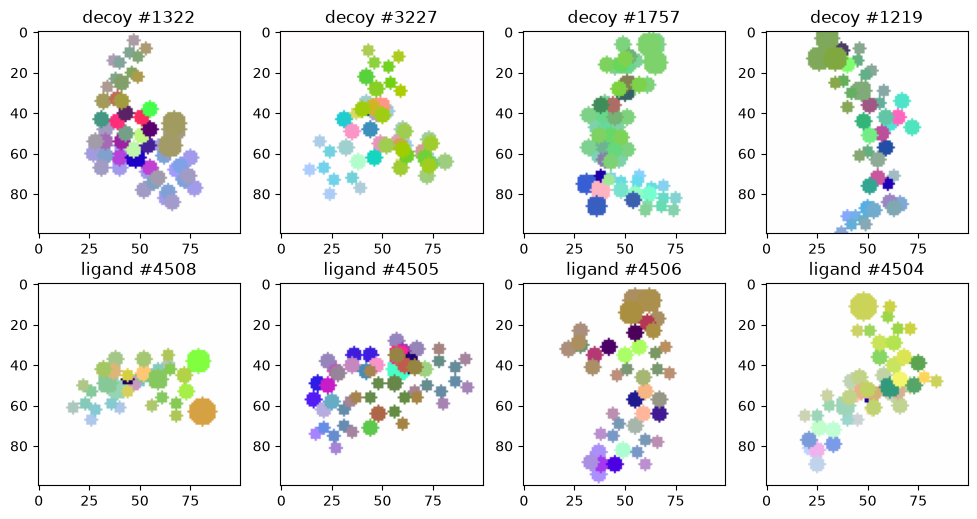

In [60]:
import torch

dec_idx = (y == 0).nonzero().flatten()
lig_idx = (y == 1).nonzero().flatten()

dec_pick = dec_idx[torch.randperm(len(dec_idx))[:4]]
lig_pick = lig_idx[torch.randperm(len(lig_idx))[:4]]

fig, ax = plt.subplots(2, 4, figsize=(12, 6))
for j, i in enumerate(dec_pick):
    ax[0, j].imshow(show(images_val[i, 0]))
    ax[0, j].set_title(f"decoy #{i.item()}")
for j, i in enumerate(lig_pick):
    ax[1, j].imshow(show(images_val[i, 0]))
    ax[1, j].set_title(f"ligand #{i.item()}")
plt.show()